In [46]:
from pathlib import Path

import cv2
import numpy as np
from draw import plot_label_map

from draftslice.core.io import load_image
from draftslice.core.utils.image_utils import binarize_image, rgb_to_grayscale

files = sorted(Path("../data/images").glob("*.jpg"))
print(f"Чертежей: {len(files)}")

Чертежей: 21


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt

file_names = [f.name for f in files]


def _view_img(filename: str):

    path = next(f for f in files if f.name == filename)
    img = load_image(str(path))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

In [97]:
def resize_to_long_side(image, long_side: int):
    current_side = max(image.shape[:2])
    if current_side == long_side:
        return image

    factor = long_side / float(current_side)
    interpolation = cv2.INTER_AREA if factor < 1 else cv2.INTER_CUBIC
    width = round(image.shape[1] * factor)
    height = round(image.shape[0] * factor)
    return cv2.resize(image, (width, height), interpolation=interpolation)

img = load_image(ui.result)
resized_img = resize_to_long_side(img, 2000)

In [98]:

binary = binarize_image(rgb_to_grayscale(resized_img))
img_h, img_w = binary.shape

print(f"Лист: {img_w}x{img_h} px, краски: {100 * (binary > 0).mean():.1f}%")

Лист: 2000x1253 px, краски: 3.6%


In [99]:
dist, labels = cv2.distanceTransformWithLabels(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

np.max(dist)

np.float32(9.196899)

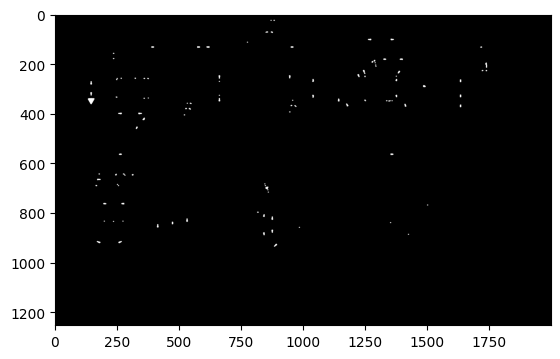

In [100]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morph_result = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)


plt.imshow(morph_result, cmap='gray')
plt.show()

In [5]:
SHEET_COVERAGE = 0.85  # длинная линия листа - тянется на такую долю стороны листа


def edge_hor(lines, content):
    """Горизонтальные длинные линии, между которыми и верхним или нижним краем нет содержимого.

    Проверка идёт только в колонках самой линии. Содержимое ближе собственной толщины линии
    не считается: это её же углы и зубцы, не прошедшие в открытие ядром высотой в 1 пиксел.
    """
    img_h = lines.shape[0]
    has = content > 0
    any_col = has.any(axis=0)
    col_top = np.where(any_col, has.argmax(axis=0), img_h)
    col_bottom = np.where(any_col, img_h - 1 - has[::-1].argmax(axis=0), -1)

    n, lbl, stats, _ = cv2.connectedComponentsWithStats(lines)
    edge = [
        i
        for i, (x, y, w, h, _) in enumerate(stats[1:], start=1)
        if col_top[x : x + w].min() >= y - h or col_bottom[x : x + w].max() <= y + 2 * h - 1
    ]
    return np.isin(lbl, edge), n - 1, len(edge)


hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(SHEET_COVERAGE * img_w), 1))
ver_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(SHEET_COVERAGE * img_h)))
hor_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, hor_kernel)
ver_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, ver_kernel)
content = cv2.subtract(binary, cv2.bitwise_or(hor_lines, ver_lines))

# Горизонтальные и вертикальные проверяются раздельно: вместе рамка стала бы одной
# компонентой с боксом на весь лист. Вертикальные - та же проверка на транспонированном листе.
hor_edge, n_hor, e_hor = edge_hor(hor_lines, content)
ver_edge, n_ver, e_ver = edge_hor(np.ascontiguousarray(ver_lines.T), np.ascontiguousarray(content.T))
binary[hor_edge | ver_edge.T] = 0

print(f"Длинных линий: {n_hor + n_ver}, с краю листа удалено: {e_hor + e_ver}")

Длинных линий: 0, с краю листа удалено: 0


In [5]:
THICKNESS_FACTOR = 5  # seed - толщина выше THICKNESS_FACTOR * средняя толщина по листу
AREA_FACTOR = 2       # seed - площадь краски выше AREA_FACTOR * средняя площадь

# Размер компоненты - короткая сторона bbox, а не длина обводки. В рукописном ГОСТовском
# шрифте буквы в слове слиты, у длинного слова суммарная длина обводки набегает как у
# целого вида - и слово уезжает в seed'ы. Короткая сторона у слова всегда равна высоте
# шрифта, и признак не зависит от поворота: у вертикальной надписи она та же.
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
comp_width = stats[1:, cv2.CC_STAT_WIDTH]
comp_height = stats[1:, cv2.CC_STAT_HEIGHT]
comp_area = stats[1:, cv2.CC_STAT_AREA]
thickness = np.minimum(comp_width, comp_height)

thickness_thresh = THICKNESS_FACTOR * thickness.mean()
area_thresh = AREA_FACTOR * comp_area.mean()

# Рамка - bbox покрывает почти весь лист по обеим осям. Выбрасывается и из seed'ов, и из
# итоговой маски.
is_frame = (comp_width >= SHEET_COVERAGE * img_w) & (comp_height >= SHEET_COVERAGE * img_h)
is_seed = (thickness > thickness_thresh) & ~is_frame

# 1-based метки: stats[1:] уже без строки фона, поэтому индекс на единицу меньше метки.
# 0 в labels - фон.
mask = binary.astype(bool)
artifact_labels = np.flatnonzero(is_frame) + 1
valid_seed_labels = np.flatnonzero(is_seed) + 1

print(f"Порог толщины: {thickness_thresh:.0f} px, порог площади: {area_thresh:.0f} px")
print(f"seed: {len(valid_seed_labels)} из {num_labels - 1}, рамок: {is_frame.sum()}")

Порог толщины: 66 px, порог площади: 312 px
seed: 3 из 418, рамок: 0


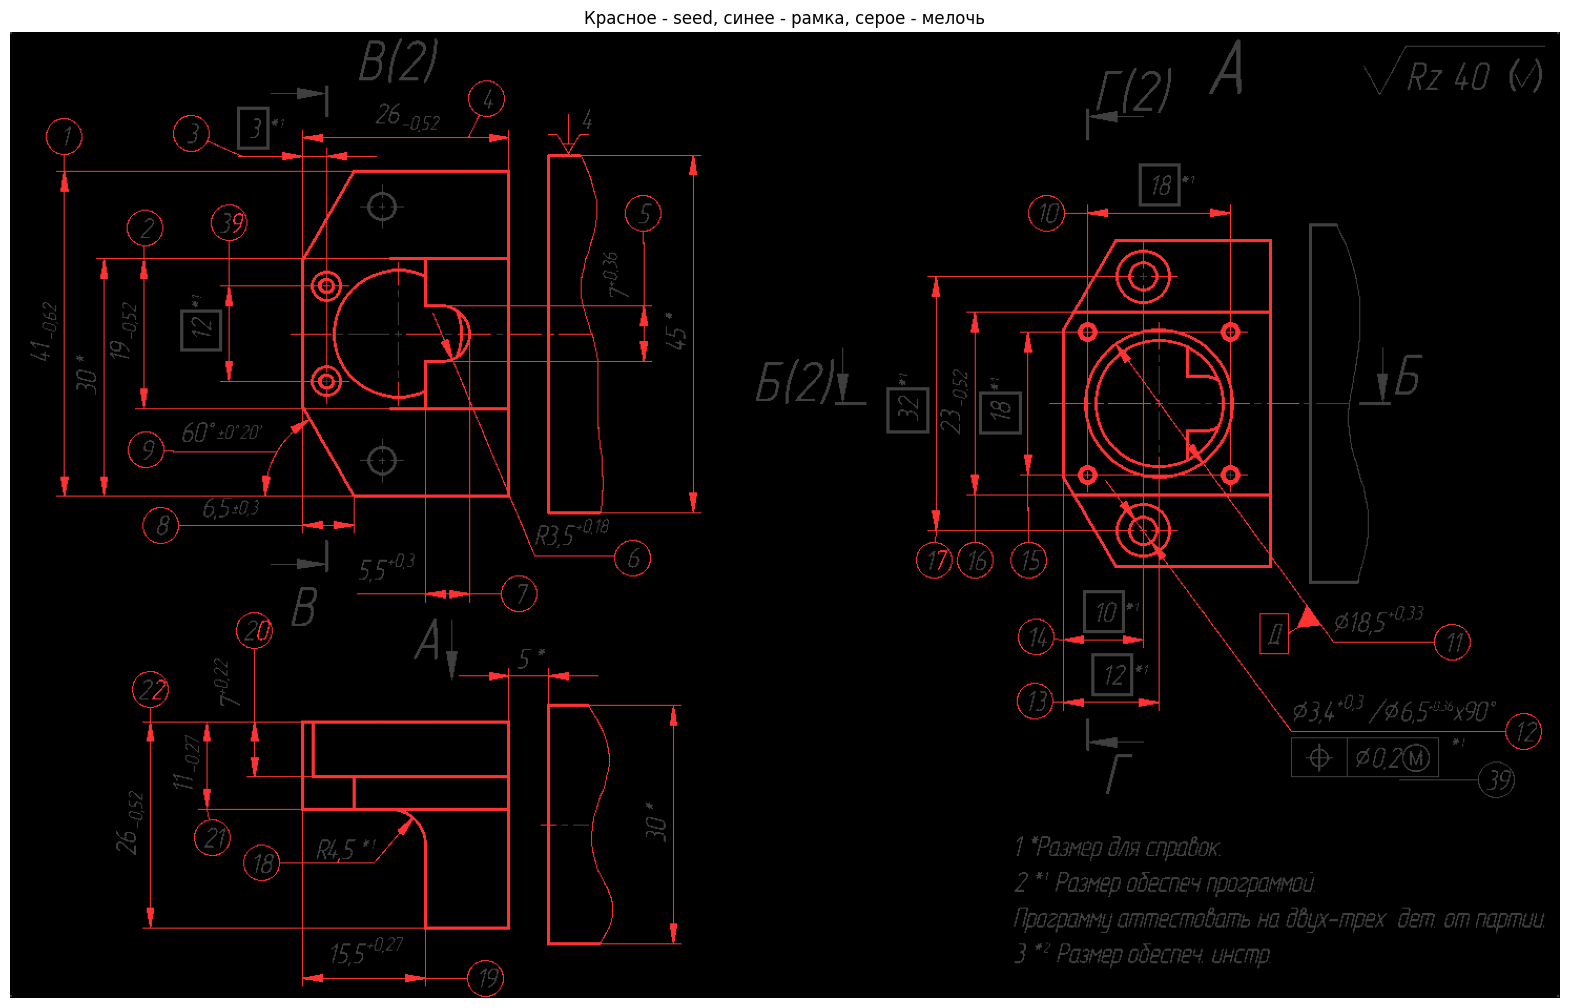

In [6]:
canvas = np.zeros((*binary.shape, 3))
canvas[mask] = 0.25
canvas[np.isin(labels, valid_seed_labels)] = (1.0, 0.2, 0.2)
canvas[np.isin(labels, artifact_labels)] = (0.2, 0.4, 1.0)

plt.figure(figsize=(20, 20))
plt.imshow(canvas)
plt.axis("off")
plt.title("Красное - seed, синее - рамка, серое - мелочь")
plt.show()

Seed'ов: 3 -> сплошных: 1.5295352895842582, вернули в мелкие: 0


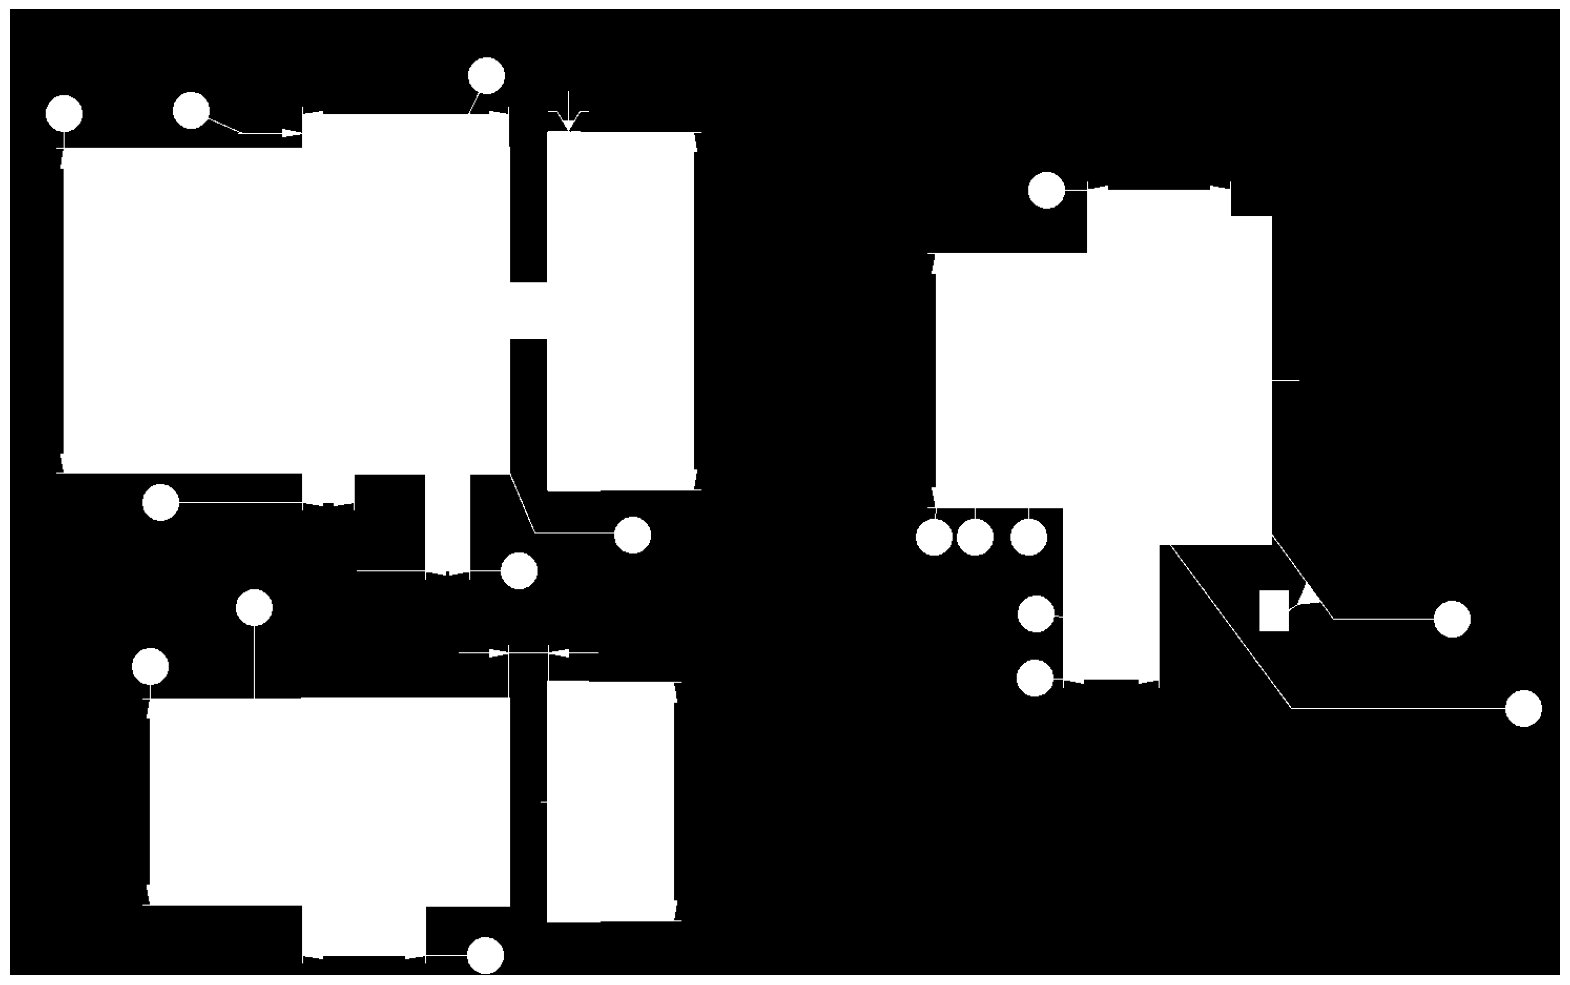

In [7]:
EXTENT = 0.1  # seed остаётся большим, если залитый контур занимает больше такой доли бокса

# Заливка внешних контуров seed-компонент: вид становится сплошным большим сегментом, и
# всё, что лежит внутри него (отверстия, штриховка, надписи поверх вида), автоматически
# оказывается в этом же сегменте.
seed_mask = np.isin(labels, valid_seed_labels).astype(np.uint8)
contours, _ = cv2.findContours(seed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Доля бокса под залитым контуром: вид после заливки сплошной, сноска с выносками - нет
# (замерено: виды 20-69%, сноска 6%).
boxes = np.array([cv2.boundingRect(c) for c in contours])
extent = np.array([cv2.contourArea(c) for c in contours]) / (boxes[:, 2] * boxes[:, 3])
is_solid = extent

# Раскинутые seed'ы уходят обратно в мелкие: метку берём с точки их контура - она лежит
# на пикселе самой компоненты.
sprawl_labels = [labels[c[0, 0, 1], c[0, 0, 0]] for c, solid in zip(contours, is_solid) if not solid]
valid_seed_labels = np.setdiff1d(valid_seed_labels, sprawl_labels)

filled = np.zeros_like(seed_mask)
cv2.drawContours(filled, [c for c, solid in zip(contours, is_solid) if solid], -1, 1, cv2.FILLED)
print(f"Seed'ов: {len(contours)} -> сплошных: {is_solid.sum()}, вернули в мелкие: {len(sprawl_labels)}")

plt.figure(figsize=(20, 20))
plt.imshow(filled, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
INSIDE = 0.5  # большие сегменты сливаются, если доля одного бокса внутри другого выше


def box_inside(x, y, w, h):
    """Доля бокса i внутри бокса j: матрица (n, n), 1.0 - i целиком внутри j."""
    area = w * h
    inter_w = np.maximum(0, np.minimum(x[:, None] + w[:, None], x + w) - np.maximum(x[:, None], x))
    inter_h = np.maximum(0, np.minimum(y[:, None] + h[:, None], y + h) - np.maximum(y[:, None], y))
    return inter_w * inter_h / area[:, None]


num_large_seg, large_seg_labels, large_seg_stats, _ = cv2.connectedComponentsWithStats(filled)
x = large_seg_stats[1:, cv2.CC_STAT_LEFT]
y = large_seg_stats[1:, cv2.CC_STAT_TOP]
w = large_seg_stats[1:, cv2.CC_STAT_WIDTH]
h = large_seg_stats[1:, cv2.CC_STAT_HEIGHT]
inside = box_inside(x, y, w, h)

# Сливаем только меньший в больший - иначе пара выберет друг друга и поменяется метками.
area = w * h
inside[area[:, None] >= area] = 0
partner = inside.argmax(axis=1)
merge = inside.max(axis=1) > INSIDE

large_seg_to_group = np.arange(num_large_seg)
large_seg_to_group[1:][merge] = partner[merge] + 1
large_seg_labels = large_seg_to_group[large_seg_labels]
print(f"Больших сегментов: {num_large_seg - 1} -> {num_large_seg - 1 - merge.sum()} "
      f"(слито по вложенности: {merge.sum()})")

Больших сегментов: 3 -> 3 (слито по вложенности: 0)


Отнесено к большим сегментам: 70.2% пикселей чертежа


<Axes: >

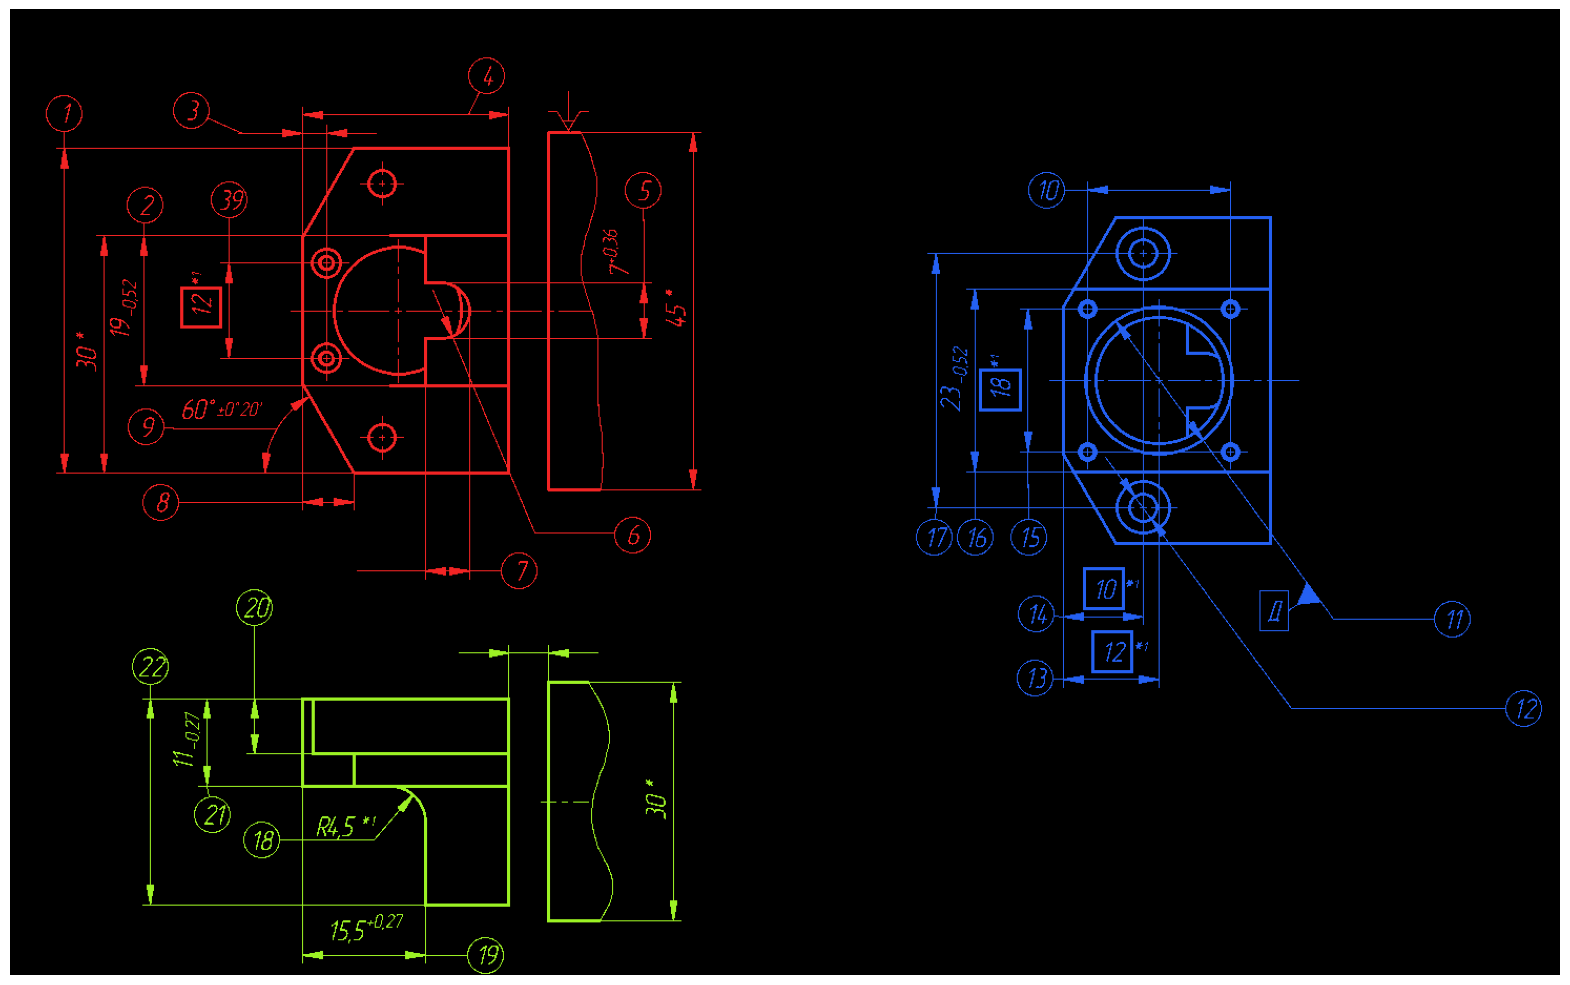

In [9]:
# Промежуточная проверка: что попало внутрь больших сегментов до раздачи мелочи.
region_image = large_seg_labels * mask
print(f"Отнесено к большим сегментам: {100 * (region_image > 0).sum() / mask.sum():.1f}% пикселей чертежа")
plot_label_map(region_image)